BREAST CANCER DATASET
Dataset Shape: (569, 30)
Classes: ['malignant' 'benign']

Training Samples: 455
Testing Samples : 114

1. DECISION TREE USING ENTROPY
Training Accuracy: 1.0
Testing Accuracy : 0.9123
Tree Depth        : 6
Number of Leaves  : 16

Classification Report:
              precision    recall  f1-score   support

   malignant       0.83      0.95      0.89        42
      benign       0.97      0.89      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

2. GINI VS ENTROPY
Criterion  Training Accuracy  Testing Accuracy  Depth  Leaves
     gini                1.0          0.912281      7      19
  entropy                1.0          0.912281      6      16

3. COST-COMPLEXITY PRUNING (CCP)
Best CCP Alpha    : 0.014264230759721015
Test Accuracy     : 0.9474
Pruned Tree Depth : 3
Pruned Tree Leaves: 7

4. DEPTH SWEEP
Best Depth       : 3
Best Test A

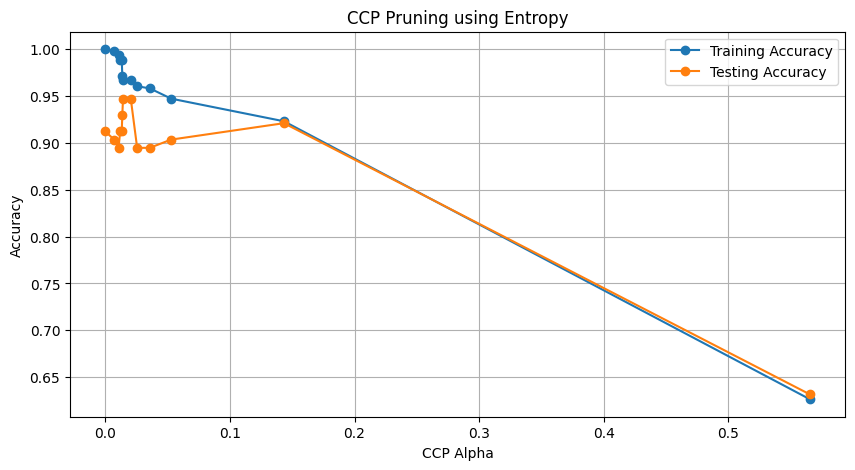

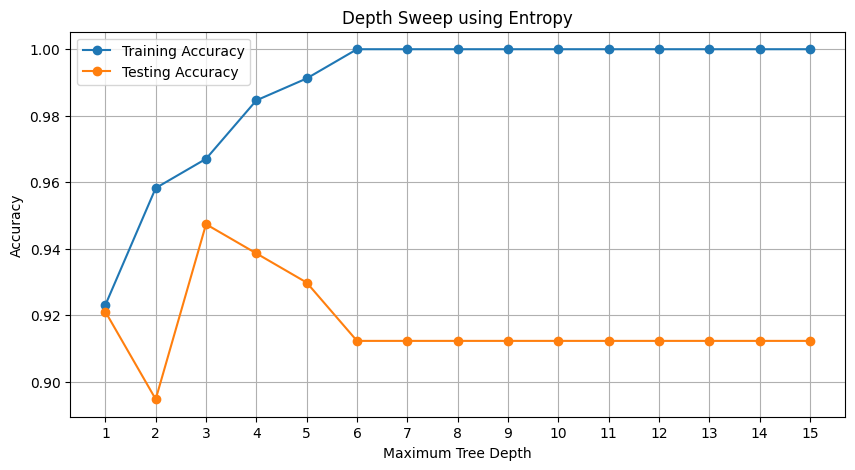

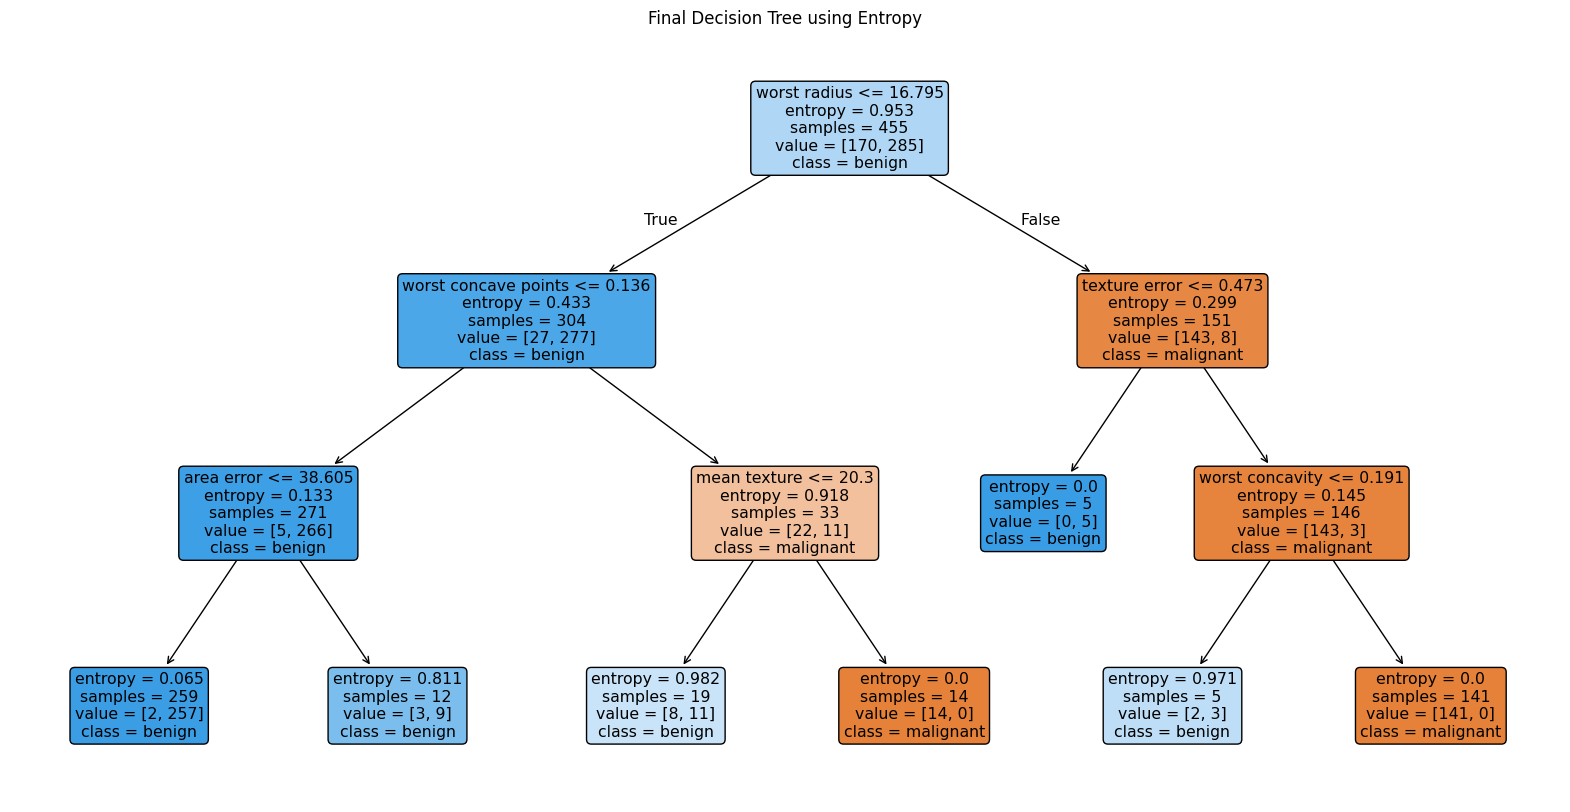


FINAL SUMMARY
                Model  Test Accuracy  Tree Depth  Leaves
 Entropy - No Pruning       0.912281           6      16
Entropy - CCP Pruning       0.947368           3       7
 Entropy - Best Depth       0.947368           3       7


In [3]:
# ============================================================
# DECISION TREE - ENTROPY, CCP PRUNING & DEPTH SWEEP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report


# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("=" * 60)
print("BREAST CANCER DATASET")
print("=" * 60)
print("Dataset Shape:", X.shape)
print("Classes:", data.target_names)


# ------------------------------------------------------------
# 2. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ------------------------------------------------------------
# 3. DECISION TREE USING ENTROPY
# ------------------------------------------------------------

dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_entropy.fit(X_train, y_train)

train_accuracy = dt_entropy.score(X_train, y_train)
test_accuracy = dt_entropy.score(X_test, y_test)

print("\n" + "=" * 60)
print("1. DECISION TREE USING ENTROPY")
print("=" * 60)

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy :", round(test_accuracy, 4))
print("Tree Depth        :", dt_entropy.get_depth())
print("Number of Leaves  :", dt_entropy.get_n_leaves())


# ------------------------------------------------------------
# 4. CLASSIFICATION REPORT
# ------------------------------------------------------------

y_pred = dt_entropy.predict(X_test)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)


# ------------------------------------------------------------
# 5. COMPARE GINI AND ENTROPY
# ------------------------------------------------------------

results = []

for criterion in ["gini", "entropy"]:

    model = DecisionTreeClassifier(
        criterion=criterion,
        random_state=42
    )

    model.fit(X_train, y_train)

    results.append([
        criterion,
        model.score(X_train, y_train),
        model.score(X_test, y_test),
        model.get_depth(),
        model.get_n_leaves()
    ])

comparison = pd.DataFrame(
    results,
    columns=[
        "Criterion",
        "Training Accuracy",
        "Testing Accuracy",
        "Depth",
        "Leaves"
    ]
)

print("=" * 60)
print("2. GINI VS ENTROPY")
print("=" * 60)

print(comparison.to_string(index=False))


# ------------------------------------------------------------
# 6. COST-COMPLEXITY PRUNING (CCP)
# ------------------------------------------------------------

path = dt_entropy.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas

train_scores = []
test_scores = []
depths_ccp = []
leaves_ccp = []

for alpha in ccp_alphas:

    model = DecisionTreeClassifier(
        criterion="entropy",
        ccp_alpha=alpha,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_scores.append(
        model.score(X_train, y_train)
    )

    test_scores.append(
        model.score(X_test, y_test)
    )

    depths_ccp.append(model.get_depth())
    leaves_ccp.append(model.get_n_leaves())


# ------------------------------------------------------------
# 7. BEST CCP ALPHA
# ------------------------------------------------------------

best_ccp_index = np.argmax(test_scores)

best_alpha = ccp_alphas[best_ccp_index]

pruned_tree = DecisionTreeClassifier(
    criterion="entropy",
    ccp_alpha=best_alpha,
    random_state=42
)

pruned_tree.fit(X_train, y_train)

pruned_accuracy = pruned_tree.score(
    X_test,
    y_test
)

print("\n" + "=" * 60)
print("3. COST-COMPLEXITY PRUNING (CCP)")
print("=" * 60)

print("Best CCP Alpha    :", best_alpha)
print("Test Accuracy     :", round(pruned_accuracy, 4))
print("Pruned Tree Depth :", pruned_tree.get_depth())
print("Pruned Tree Leaves:", pruned_tree.get_n_leaves())


# ------------------------------------------------------------
# 8. DEPTH SWEEP
# ------------------------------------------------------------

depth_range = range(1, 16)

depth_train_scores = []
depth_test_scores = []

for depth in depth_range:

    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    depth_train_scores.append(
        model.score(X_train, y_train)
    )

    depth_test_scores.append(
        model.score(X_test, y_test)
    )


# ------------------------------------------------------------
# 9. BEST DEPTH
# ------------------------------------------------------------

best_depth_index = np.argmax(depth_test_scores)

best_depth = list(depth_range)[best_depth_index]
best_depth_accuracy = depth_test_scores[best_depth_index]

final_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=best_depth,
    random_state=42
)

final_model.fit(X_train, y_train)

print("\n" + "=" * 60)
print("4. DEPTH SWEEP")
print("=" * 60)

print("Best Depth       :", best_depth)
print("Best Test Accuracy:", round(best_depth_accuracy, 4))
print("Number of Leaves :", final_model.get_n_leaves())


# ------------------------------------------------------------
# 10. FINAL MODEL REPORT
# ------------------------------------------------------------

final_pred = final_model.predict(X_test)

print("\nFinal Classification Report:")
print(
    classification_report(
        y_test,
        final_pred,
        target_names=data.target_names
    )
)


# ------------------------------------------------------------
# 11. PLOT CCP PRUNING
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    ccp_alphas,
    train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    ccp_alphas,
    test_scores,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("CCP Alpha")
plt.ylabel("Accuracy")
plt.title("CCP Pruning using Entropy")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 12. PLOT DEPTH SWEEP
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    list(depth_range),
    depth_train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    list(depth_range),
    depth_test_scores,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Depth Sweep using Entropy")
plt.xticks(list(depth_range))
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 13. FINAL DECISION TREE VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(20, 10))

plot_tree(
    final_model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Final Decision Tree using Entropy")
plt.show()


# ------------------------------------------------------------
# 14. FINAL SUMMARY
# ------------------------------------------------------------

summary = pd.DataFrame({
    "Model": [
        "Entropy - No Pruning",
        "Entropy - CCP Pruning",
        "Entropy - Best Depth"
    ],
    "Test Accuracy": [
        dt_entropy.score(X_test, y_test),
        pruned_tree.score(X_test, y_test),
        final_model.score(X_test, y_test)
    ],
    "Tree Depth": [
        dt_entropy.get_depth(),
        pruned_tree.get_depth(),
        final_model.get_depth()
    ],
    "Leaves": [
        dt_entropy.get_n_leaves(),
        pruned_tree.get_n_leaves(),
        final_model.get_n_leaves()
    ]
})

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(summary.to_string(index=False))